# How to calculate the spatial gradient of a scalar field in cartesian coordiantes

FELiCS can be used to calculate the spatial gradient of a quantity with a few commands. Here, the following cases are described:
- cartesian coordinates: square 2D domain
- cartesian coordinates with spectral dimension: the de-facto 2D domain can be imagined as a 3D channel, which is periodically expanded in the third direction

### Cartesian coordinates on a 2D domain
Here, the gradient of a scalar field on a square 2D mesh is computed. We define our scalar field as follows:
$$\phi(x,y) = \sin(2\pi x)\cos(2\pi y)$$


**Step 1: Create FELiCSMesh, FELiCSSpace and Field**

In [10]:
from FELiCS.SpaceDisc.FELiCSMesh import FELiCSMesh
from FELiCS.SpaceDisc.FEMSpaces  import createFunctionSpace
from FELiCS.Fields.Field         import Field
from FELiCS.IO.Reader            import Reader

meshFileName = "./square_mesh.msh"
coordinateSystemName = "Cartesian"

# create a FELiCS mesh from the gmsh file
mesh = FELiCSMesh(coordinateSystemName, meshFileName)

# create a scalar space
scalarSpace = createFunctionSpace(mesh, degree=2, dim=1)

# create a Field object and import the data from the h5 file
phi = Field(scalarSpace, mesh=mesh, name="function_sine_cos") 
phi.importData(Reader(), "input.h5")


Info     | FELiCSMesh.py          | __init__                   (line 75  ) : Opening mesh file: ./square_mesh.msh
Info     | FELiCSMesh.py          | __init__                   (line 83  ) : Mesh contains 513 nodes and 1024 elements


(<FELiCS.Fields.Field.Field at 0x73f2542f9130>, [])

**Step 2: Get gradient as a vector field and extract the scalar fields**

We now want to calculate the gradient of our scalar quantity using the `getGradientField()` method of our Field class. This method returns a Field object, which represents a vector-field as we calculate the gradient of a scalar with respect to our two spatial and one spectral dimension. The gradient is defined as
$$\nabla \phi = \left(\frac{\partial \phi}{\partial x}, \frac{\partial \phi}{\partial y}\right)\ .$$
So for our function the analytical gradient is
$$\nabla \phi = \begin{pmatrix}
2\pi \cos(2\pi x) \cos(2\pi y) \\
-2\pi \sin(2\pi x) \sin(2\pi y) 
\end{pmatrix}\ .$$ 
The resulting field is defined on a vector space with 2 dimension. We can also transform it in two scalar fields via the command 'getListOfSingleFields()'.

In [2]:
gradPhi = phi.getGradientField() # this is a vector field

# get scalar fields from gradient:
gradList = gradPhi.getListOfSubFields()
phi_x    = gradList[0]
phi_y    = gradList[1]

**Step 2: Postprocessing**

Exporting as h5 file and visualization of the gradients by using the FELiCS plotting function:

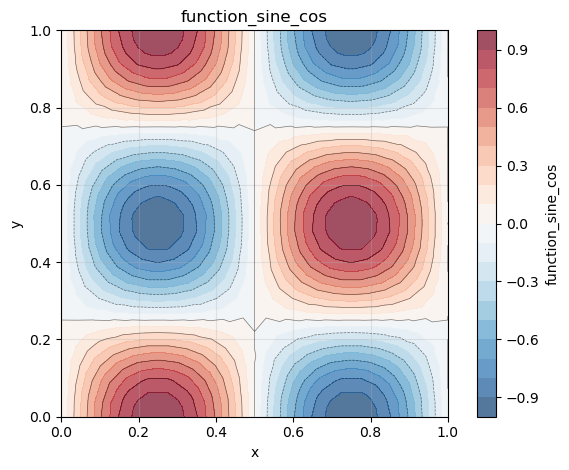

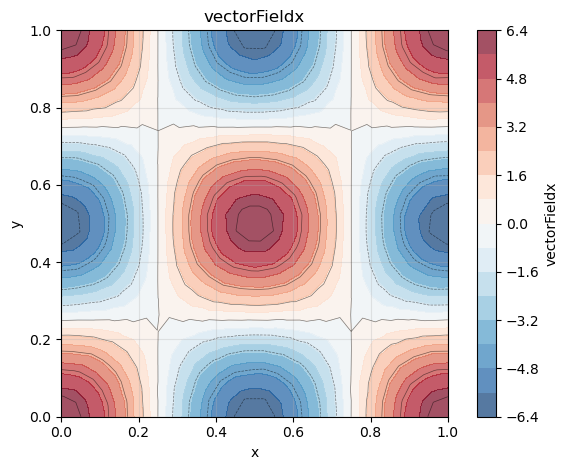

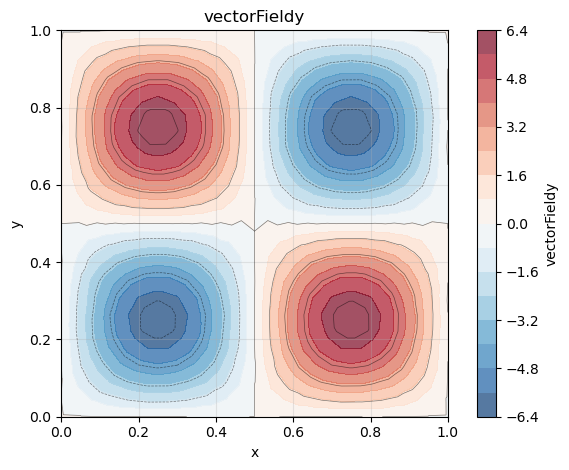

In [3]:
from FELiCS.IO.Writer import Writer
gradPhi.exportToH5(Writer())

phi.plot()
phi_x.plot()
phi_y.plot()

### Cartesian coordinates with spectral dimension
Here, to the two spatial dimensions (x and y) a third spectral dimension in z-direction is added.
With the spectral dimension the scalar field becomes
$$\phi \cdot e^{imz}$$
where m is the wave number. With the wave number we represent a periodicity of the flow in z-direction, while still only calculating a 2D flowfield.

**Step 1: Create FELiCSMesh, FELiCSSpace and Field**

In [4]:
from FELiCS.SpaceDisc.FELiCSMesh import FELiCSMesh
from FELiCS.SpaceDisc.FEMSpaces  import createFunctionSpace
from FELiCS.Fields.Field         import Field
from FELiCS.IO.Reader            import Reader

meshFileName = "./square_mesh.msh"
coordinateSystemName = "Cartesian"
m = 3

# create a FELiCS mesh from the gmsh file
# by setting m to an integer number that is not zero, the spectral direction is added to the coordinate system
mesh = FELiCSMesh(coordinateSystemName, meshFileName, m=m) 

# create a scalar space
scalarSpace = createFunctionSpace(mesh, degree=2, dim=1)

# create a Field object and import the data from the h5 file
# by setting m to an integer number that is not zero, the spectral direction is added to the field
phi = Field(scalarSpace, mesh=mesh, name = "function_sine_cos", m = m) 
phi.importData(Reader(),"input.h5")


Info     | FELiCSMesh.py          | __init__                   (line 75  ) : Opening mesh file: ./square_mesh.msh
Info     | FELiCSMesh.py          | __init__                   (line 83  ) : Mesh contains 513 nodes and 1024 elements


(<FELiCS.Fields.Field.Field at 0x73f2548ad650>, [])

**Step 2: Calculate the gradient**

With the spectral dimension, the gradient is now 3-dimensional:
$$\nabla \phi = \left(\frac{\partial \phi}{\partial x}, \frac{\partial \phi}{\partial y}, \frac{\partial \phi}{\partial z}\right)$$
and it is defined as:
$$\nabla \phi = \begin{pmatrix}
2\pi \cos(2\pi x) \cos(2\pi y) \cdot e^{imz} \\
-2\pi \sin(2\pi x) \sin(2\pi y) \cdot e^{imz} \\
im \sin(2\pi x) \cos(2\pi y) \cdot e^{imz}
\end{pmatrix}\ .$$
Note that the derivative in the spectral dimension is imaginary. 

In [8]:
gradPhi = phi.getGradientField() # this is a vector field

# get scalar fields from gradient:
gradList = gradPhi.getListOfSubFields()
phi_x    = gradList[0]
phi_y    = gradList[1]
phi_z    = gradList[2]

**Step 3: Postprocessing**

Exporting as h5 file and visualization of the gradients by using the FELiCS plotting function:


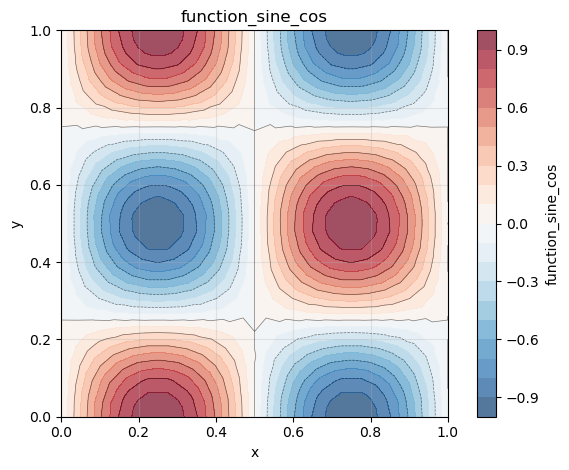

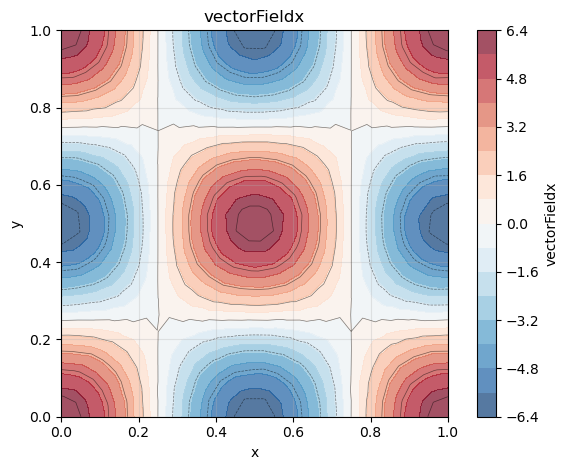

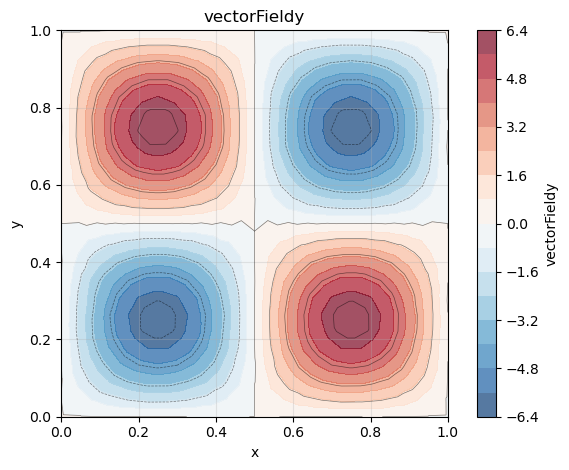

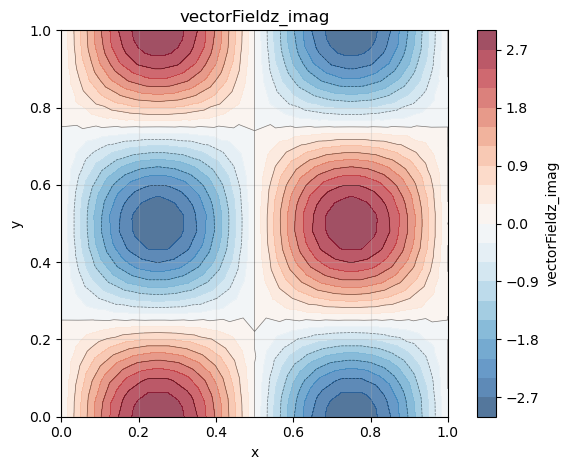

In [9]:
from FELiCS.IO.Writer import Writer
gradPhi.exportToH5(Writer())

phi.plot()
phi_x.plot()
phi_y.plot()
phi_z.plot(imaginaryPart=True)